In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import make_scorer
from sklearn.metrics import roc_auc_score
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from optuna.pruners import MedianPruner

c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_excel(r"C:\Users\User\Desktop\ЦФА вторичный.xlsx", sheet_name = 'Total')

In [3]:
df_logit = df.copy()

In [4]:
df_logit.sample(5)

,Название,Эмитент,Тип ЦФА,Глубина стакана,Количество заявок на покупку,Bid,Активов покупается,Ask,Количество заявок на продажу,Активов продается,...,Дата выпуска,Срок погашения,Можно продать после,Тип процентной ставки,"Срок обращения, мес","Накопленный процентный доход, руб",Выплата процентного дохода,Рейтинг РА эмитента,ОИС,КС на момент выпуска %
20,Альфа-Банк-710,Альфа-Банк,Цифровые обязательства,10,10,1052.0,4209,0.0,0,0,...,2025-02-28,2027-02-26,2025-02-28,Фиксированная,24,NaN,В конце срока,AA+,А-токен,21.0
143,Альфа-Банк-1561,Альфа-Банк,Цифровые обязательства,3,3,1002.0,739,0.0,0,0,...,2026-03-06,2026-06-05,2026-03-06,Фиксированная,3,32.88,В конце срока,AA+,А-токен,15.5
145,Альфамонолит-3,Альфамонолит,Цифровые обязательства,5,4,1039.0,59,900.0,1,6,...,2026-03-06,2026-09-04,2026-09-04,Фиксированная,6,Na,Ежемесячно,NaN,Токеон,15.5
17,Альфа-Банк-697,Альфа-Банк,Цифровые обязательства,7,7,1111.0,2238,0.0,0,0,...,2025-02-15,2028-02-11,2025-02-17,Фиксированная,36,NaN,В конце срока,AA+,А-токен,21.0
180,Siberian Wellness - 1,"ГК ""Сибирское здоровье""",Цифровые обязательства,16,9,1010.0,677,1049.0,7,116,...,2026-03-26,2027-03-26,2026-03-27,Фиксированная,12,3.45,Ежемесячно,NaN,А-токен,15.0


In [5]:
df_logit.columns

Index(['Название', 'Эмитент', 'Тип ЦФА', 'Глубина стакана',
       'Количество заявок на покупку', 'Bid', 'Активов покупается', 'Ask',
       'Количество заявок на продажу', 'Активов продается', 'Процент', 'Цена',
       'Номинал', 'Дата выпуска', 'Срок погашения', 'Можно продать после',
       'Тип процентной ставки', 'Срок обращения, мес',
       'Накопленный процентный доход, руб', 'Выплата процентного дохода',
       'Рейтинг РА эмитента', 'ОИС', 'КС на момент выпуска %'],
      dtype='object')

In [6]:
df_logit.isna().sum()

Название                              0
Эмитент                               0
Тип ЦФА                               0
Глубина стакана                       0
Количество заявок на покупку          0
Bid                                   0
Активов покупается                    0
Ask                                   0
Количество заявок на продажу          0
Активов продается                     0
Процент                              23
Цена                                 12
Номинал                               0
Дата выпуска                          0
Срок погашения                        0
Можно продать после                  25
Тип процентной ставки                 0
Срок обращения, мес                   0
Накопленный процентный доход, руб    90
Выплата процентного дохода           20
Рейтинг РА эмитента                  62
ОИС                                   0
КС на момент выпуска %                0
dtype: int64

In [7]:
df_logit['liqu'] = df_logit.apply(lambda x: 1 if (x['Количество заявок на покупку'] > 0) & (x['Количество заявок на продажу'] > 0) else 0, axis = 1 )

In [8]:
df_logit

,Название,Эмитент,Тип ЦФА,Глубина стакана,Количество заявок на покупку,Bid,Активов покупается,Ask,Количество заявок на продажу,Активов продается,...,Срок погашения,Можно продать после,Тип процентной ставки,"Срок обращения, мес","Накопленный процентный доход, руб",Выплата процентного дохода,Рейтинг РА эмитента,ОИС,КС на момент выпуска %,liqu
0,Autocity-1,"ООО ""Автосити""",Цифровые обязательства,15,5,105.00,631,305.00,10,38,...,2030-06-26,2024-06-27,Фиксированная,12,NaN,Ежемесячно,NaN,А-токен,16.0,1
1,Альфа-Банк-394,Альфа-Банк,Цифровые обязательства,9,9,1006.00,2836,0.00,0,0,...,2027-10-29,2024-11-01,Фиксированная,36,NaN,В конце срока,AA+,А-токен,21.0,0
2,Альфа-Банк-430,Альфа-Банк,Цифровые обязательства,12,12,1013.00,1686,0.00,0,0,...,2027-11-08,2024-11-11,Фиксированная,36,NaN,В конце срока,AA+,А-токен,21.0,0
3,Альфа-Банк-434,Альфа-Банк,Цифровые обязательства,8,8,1200.00,5176,0.00,0,0,...,2026-11-09,2024-11-11,Фиксированная,24,NaN,В конце срока,AA+,А-токен,21.0,0
4,Альфа-Банк-440,Альфа-Банк,Цифровые обязательства,9,9,1200.00,3416,0.00,0,0,...,2026-05-13,2024-11-13,Фиксированная,18,NaN,В конце срока,AA+,А-токен,21.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
194,Альфамонолит-4,Альфамонолит,Цифровые обязательства,3,1,1100.00,3,900.00,2,20,...,2027-01-20,2027-01-20,Фиксированная,7,Na,Ежемесячно,NaN,Токеон,15.0,1
195,Альфа-Банк-1653,Альфа-Банк,Цифровые обязательства,5,5,1007.00,295,0.00,0,0,...,2026-10-22,2026-04-22,Фиксированная,6,5.09,В конце срока,AA+,А-токен,15.0,0
196,Дельта-агро-4,Дельта-агро,Цифровые обязательства,4,3,1044.99,53,1000.00,1,11,...,2027-01-22,2027-01-22,Фиксированная,7,Na,Ежемесячно,NaN,Токеон,15.0,1
197,"ТК ""Мерокс""-1","ТК ""Мерокс""",Цифровые обязательства,2,1,1100.00,86,1000.00,1,5,...,2026-07-30,2026-07-30,Фиксированная,3,Na,Ежемесячно,NaN,Токеон,14.5,1


In [9]:
df_logit['liqu'].value_counts()

liqu
1    111
0     88
Name: count, dtype: int64

In [10]:
df_logit.isna().sum()

Название                              0
Эмитент                               0
Тип ЦФА                               0
Глубина стакана                       0
Количество заявок на покупку          0
Bid                                   0
Активов покупается                    0
Ask                                   0
Количество заявок на продажу          0
Активов продается                     0
Процент                              23
Цена                                 12
Номинал                               0
Дата выпуска                          0
Срок погашения                        0
Можно продать после                  25
Тип процентной ставки                 0
Срок обращения, мес                   0
Накопленный процентный доход, руб    90
Выплата процентного дохода           20
Рейтинг РА эмитента                  62
ОИС                                   0
КС на момент выпуска %                0
liqu                                  0
dtype: int64

In [11]:
df_logit['Рейтинг РА эмитента'] = df_logit['Рейтинг РА эмитента'].fillna('Без рейтинга')

In [12]:
df_logit.isna().sum()

Название                              0
Эмитент                               0
Тип ЦФА                               0
Глубина стакана                       0
Количество заявок на покупку          0
Bid                                   0
Активов покупается                    0
Ask                                   0
Количество заявок на продажу          0
Активов продается                     0
Процент                              23
Цена                                 12
Номинал                               0
Дата выпуска                          0
Срок погашения                        0
Можно продать после                  25
Тип процентной ставки                 0
Срок обращения, мес                   0
Накопленный процентный доход, руб    90
Выплата процентного дохода           20
Рейтинг РА эмитента                   0
ОИС                                   0
КС на момент выпуска %                0
liqu                                  0
dtype: int64

In [13]:
df_logit = df_logit.drop('Можно продать после', axis = 1)

In [14]:
df_logit.isna().sum()

Название                              0
Эмитент                               0
Тип ЦФА                               0
Глубина стакана                       0
Количество заявок на покупку          0
Bid                                   0
Активов покупается                    0
Ask                                   0
Количество заявок на продажу          0
Активов продается                     0
Процент                              23
Цена                                 12
Номинал                               0
Дата выпуска                          0
Срок погашения                        0
Тип процентной ставки                 0
Срок обращения, мес                   0
Накопленный процентный доход, руб    90
Выплата процентного дохода           20
Рейтинг РА эмитента                   0
ОИС                                   0
КС на момент выпуска %                0
liqu                                  0
dtype: int64

In [15]:
df_logit.loc[df_logit['Цена'].isna()]

,Название,Эмитент,Тип ЦФА,Глубина стакана,Количество заявок на покупку,Bid,Активов покупается,Ask,Количество заявок на продажу,Активов продается,...,Дата выпуска,Срок погашения,Тип процентной ставки,"Срок обращения, мес","Накопленный процентный доход, руб",Выплата процентного дохода,Рейтинг РА эмитента,ОИС,КС на момент выпуска %,liqu
27,Медскан-1,Медскан,Цифровые обязательства,1,1,1100.00,34,0.0,0,0,...,2025-05-26,2026-05-26,Фиксированная,12,Na,Ежемесячно,Без рейтинга,Токеон,21.0,0
28,Re-Token-1,ООО «Реиннольц»,Цифровые обязательства,2,2,1030.00,63,0.0,0,0,...,2025-06-03,2026-06-09,Фиксированная,12,23.04,Ежемесячно,Без рейтинга,Токеон,21.0,0
98,Салюс-2,Салюс,Цифровые обязательства,1,1,1100.00,9,0.0,0,0,...,2025-12-30,2026-09-01,Фиксированная,10,Na,Ежемесячно,Без рейтинга,Токеон,16.0,0
116,Альфамонолит-2,Альфамонолиит,Цифровые обязательства,15,7,1030.00,434,900.0,8,14,...,2026-02-06,2026-08-06,Фиксированная,6,Na,Ежемесячно,Без рейтинга,Токеон,16.0,1
126,Дельта-агро-3,Дельта-агро,Цифровые обязательства,1,0,0.00,0,1000.0,1,11,...,2026-02-13,2026-11-13,Фиксированная,9,Na,Ежемесячно,Без рейтинга,Токеон,16.0,0
145,Альфамонолит-3,Альфамонолит,Цифровые обязательства,5,4,1039.00,59,900.0,1,6,...,2026-03-06,2026-09-04,Фиксированная,6,Na,Ежемесячно,Без рейтинга,Токеон,15.5,1
173,ГТЛК -1,"АО ""ГТЛК""",Цифровые обязательства,2,2,1199.00,45,0.0,0,0,...,2026-03-20,2026-06-19,Привязка к индексу,3,Na,Ежемесячно,AA-,Токеон,15.5,0
182,A7-USD-2,"ООО ""А7""",Цифровые обязательства,1,0,0.00,0,70.2,1,13,...,2026-03-27,2026-05-27,Привязка к индексу,2,Na,В конце срока,АА (АКРА),Токеон,15.0,0
191,Цифровое вино и Цифровой градус -11,ООО «ЛУДИНГ»,ГЦП,1,1,10000.00,1,0.0,0,0,...,2026-04-13,2026-10-13,Привязка к индексу,6,Na,В конце срока,Без рейтинга,Токеон,15.0,0
194,Альфамонолит-4,Альфамонолит,Цифровые обязательства,3,1,1100.00,3,900.0,2,20,...,2026-04-20,2027-01-20,Фиксированная,7,Na,Ежемесячно,Без рейтинга,Токеон,15.0,1


In [16]:
df_logit['Цена'] = df_logit['Цена'].fillna((df_logit['Bid'] + df_logit['Ask'])/2)

In [17]:
df_logit.isna().sum()

Название                              0
Эмитент                               0
Тип ЦФА                               0
Глубина стакана                       0
Количество заявок на покупку          0
Bid                                   0
Активов покупается                    0
Ask                                   0
Количество заявок на продажу          0
Активов продается                     0
Процент                              23
Цена                                  0
Номинал                               0
Дата выпуска                          0
Срок погашения                        0
Тип процентной ставки                 0
Срок обращения, мес                   0
Накопленный процентный доход, руб    90
Выплата процентного дохода           20
Рейтинг РА эмитента                   0
ОИС                                   0
КС на момент выпуска %                0
liqu                                  0
dtype: int64

In [18]:
check_pay = df_logit.loc[df_logit['Выплата процентного дохода'].isna()]
check_pay['Тип ЦФА'].unique()

array(['Золото'], dtype=object)

In [19]:
df_logit['Выплата процентного дохода'] = df_logit['Выплата процентного дохода'].fillna('В конце срока')

In [20]:
df_logit['Выплата процентного дохода'].value_counts()

Выплата процентного дохода
Ежемесячно       103
В конце срока     94
Ежеквартально      2
Name: count, dtype: int64

In [21]:
df_logit.isna().sum()

Название                              0
Эмитент                               0
Тип ЦФА                               0
Глубина стакана                       0
Количество заявок на покупку          0
Bid                                   0
Активов покупается                    0
Ask                                   0
Количество заявок на продажу          0
Активов продается                     0
Процент                              23
Цена                                  0
Номинал                               0
Дата выпуска                          0
Срок погашения                        0
Тип процентной ставки                 0
Срок обращения, мес                   0
Накопленный процентный доход, руб    90
Выплата процентного дохода            0
Рейтинг РА эмитента                   0
ОИС                                   0
КС на момент выпуска %                0
liqu                                  0
dtype: int64

In [22]:
df_logit = df_logit.drop('Накопленный процентный доход, руб', axis = 1)

In [23]:
df_logit.isna().sum()

Название                         0
Эмитент                          0
Тип ЦФА                          0
Глубина стакана                  0
Количество заявок на покупку     0
Bid                              0
Активов покупается               0
Ask                              0
Количество заявок на продажу     0
Активов продается                0
Процент                         23
Цена                             0
Номинал                          0
Дата выпуска                     0
Срок погашения                   0
Тип процентной ставки            0
Срок обращения, мес              0
Выплата процентного дохода       0
Рейтинг РА эмитента              0
ОИС                              0
КС на момент выпуска %           0
liqu                             0
dtype: int64

In [24]:
df_logit

,Название,Эмитент,Тип ЦФА,Глубина стакана,Количество заявок на покупку,Bid,Активов покупается,Ask,Количество заявок на продажу,Активов продается,...,Номинал,Дата выпуска,Срок погашения,Тип процентной ставки,"Срок обращения, мес",Выплата процентного дохода,Рейтинг РА эмитента,ОИС,КС на момент выпуска %,liqu
0,Autocity-1,"ООО ""Автосити""",Цифровые обязательства,15,5,105.00,631,305.00,10,38,...,1000.0,2024-06-26,2030-06-26,Фиксированная,12,Ежемесячно,Без рейтинга,А-токен,16.0,1
1,Альфа-Банк-394,Альфа-Банк,Цифровые обязательства,9,9,1006.00,2836,0.00,0,0,...,1000.0,2024-11-01,2027-10-29,Фиксированная,36,В конце срока,AA+,А-токен,21.0,0
2,Альфа-Банк-430,Альфа-Банк,Цифровые обязательства,12,12,1013.00,1686,0.00,0,0,...,1000.0,2024-11-09,2027-11-08,Фиксированная,36,В конце срока,AA+,А-токен,21.0,0
3,Альфа-Банк-434,Альфа-Банк,Цифровые обязательства,8,8,1200.00,5176,0.00,0,0,...,1000.0,2024-11-09,2026-11-09,Фиксированная,24,В конце срока,AA+,А-токен,21.0,0
4,Альфа-Банк-440,Альфа-Банк,Цифровые обязательства,9,9,1200.00,3416,0.00,0,0,...,1000.0,2024-11-13,2026-05-13,Фиксированная,18,В конце срока,AA+,А-токен,21.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
194,Альфамонолит-4,Альфамонолит,Цифровые обязательства,3,1,1100.00,3,900.00,2,20,...,1000.0,2026-04-20,2027-01-20,Фиксированная,7,Ежемесячно,Без рейтинга,Токеон,15.0,1
195,Альфа-Банк-1653,Альфа-Банк,Цифровые обязательства,5,5,1007.00,295,0.00,0,0,...,1000.0,2026-04-22,2026-10-22,Фиксированная,6,В конце срока,AA+,А-токен,15.0,0
196,Дельта-агро-4,Дельта-агро,Цифровые обязательства,4,3,1044.99,53,1000.00,1,11,...,1000.0,2026-04-22,2027-01-22,Фиксированная,7,Ежемесячно,Без рейтинга,Токеон,15.0,1
197,"ТК ""Мерокс""-1","ТК ""Мерокс""",Цифровые обязательства,2,1,1100.00,86,1000.00,1,5,...,1000.0,2026-04-30,2026-07-30,Фиксированная,3,Ежемесячно,Без рейтинга,Токеон,14.5,1


In [25]:
df_logit.columns

Index(['Название', 'Эмитент', 'Тип ЦФА', 'Глубина стакана',
       'Количество заявок на покупку', 'Bid', 'Активов покупается', 'Ask',
       'Количество заявок на продажу', 'Активов продается', 'Процент', 'Цена',
       'Номинал', 'Дата выпуска', 'Срок погашения', 'Тип процентной ставки',
       'Срок обращения, мес', 'Выплата процентного дохода',
       'Рейтинг РА эмитента', 'ОИС', 'КС на момент выпуска %', 'liqu'],
      dtype='object')

In [26]:
check_1 = df_logit['Эмитент'].value_counts()

In [27]:
check_1

Эмитент
Альфа-Банк                 89
ПАО "Евротранс"            13
АО "Дельта-Агро"            5
ООО "Форте Хоум ГмбХ"       5
Группа "ВИС" (АО)           5
                           ..
"АгроТерра"                 1
ООО «ЛУДИНГ»                1
АО "ГК "ЕКС"                1
ТК "Мерокс"                 1
ООО "Балтийский лизинг"     1
Name: count, Length: 66, dtype: int64

In [28]:
df_logit['Эмитент'].unique()

array(['ООО "Автосити"', 'Альфа-Банк', 'ООО "МСБ-Лизинг"',
       'ООО "Форте Хоум ГмбХ"', 'Группа Магнезит',
       'АО "Новосибирскавтодор"', 'Доброфлот', 'ООО "ПК"', 'Медскан',
       'ООО «Реиннольц»', 'ПАО "Евротранс"', 'Kitfort', 'ПАО "Глоракс"',
       'МКПАО "Т-Технологии"', 'Селигдар', 'ООО "Новые технологии"',
       'AVA', 'ООО "Прометей"', 'ООО "УК "ТЕРМОЛЭНД"',
       'Вольгинский завод литьевых пластмасс', 'ARLIFT', 'ООО "НЬЮФЭШН"',
       'ООО "Рестор"', 'ООО "Завод Светодиоидной продуукции"',
       'АО "Дельта-Агро"', 'ГК "Первый капитал"', 'ООО "ЭКОНИВА-ТЕХНИКА"',
       'Золотое Яблоко', 'Эталон', 'АО "Аэроклуб"',
       'ООО "Сервис-Интегратор"', 'ЭНКО', 'ГК "Полипласт"',
       'АО "Медскан"', 'ООО "Тальвен"', 'Аптеки Плюс', 'ООО "ПНПЗ"',
       'ООО "Дымовское колбасное производство"', 'ПАО АФК "Система"',
       'Группа "ВИС" (АО)', 'ООО "ВФМ ТЕХНОЛОДЖИ"', 'ГК "Семья"',
       'Сибресурс', 'Салюс', 'Альфамонолиит', 'Группа ДАРС',
       'Дельта-агро', 'ООО "Балти

In [29]:
catrgorical = ['Эмитент', 'Тип ЦФА',  'Тип процентной ставки', 'Выплата процентного дохода', 'Рейтинг РА эмитента', 'ОИС']


numerical = ['Процент', 'Цена', 'Номинал', 'Срок обращения, мес', 'КС на момент выпуска %']#удалил остальные признаки, так как если предполагать, что ликвидность это наличие bid и ask, то это может быть утечкой 

In [30]:
total_features = catrgorical + numerical

In [31]:
total_features

['Эмитент',
 'Тип ЦФА',
 'Тип процентной ставки',
 'Выплата процентного дохода',
 'Рейтинг РА эмитента',
 'ОИС',
 'Процент',
 'Цена',
 'Номинал',
 'Срок обращения, мес',
 'КС на момент выпуска %']

---

Сгруппируем эмитентов, так как их оказывается слишком много

---

In [32]:
df_logit['emitnet_group'] = df_logit.groupby('Эмитент')['Эмитент'].transform('count') > 5

In [33]:
df_logit = df_logit.drop('emitnet_group', axis = 1)

In [34]:
pd.set_option('display.max_rows', None)

In [35]:
pd.reset_option('display.max_rows')

In [36]:
print(check_1)

Эмитент
Альфа-Банк                 89
ПАО "Евротранс"            13
АО "Дельта-Агро"            5
ООО "Форте Хоум ГмбХ"       5
Группа "ВИС" (АО)           5
                           ..
"АгроТерра"                 1
ООО «ЛУДИНГ»                1
АО "ГК "ЕКС"                1
ТК "Мерокс"                 1
ООО "Балтийский лизинг"     1
Name: count, Length: 66, dtype: int64


In [37]:
rare_emitors = check_1[check_1 < 2].index

In [38]:
rare_emitors

Index(['ООО "Автосити"', 'ООО "Прометей"', 'МКПАО "Т-Технологии"', 'Kitfort',
       'ООО «Реиннольц»', 'ГК "Первый капитал"',
       'ООО "Завод Светодиоидной продуукции"', 'ARLIFT', 'ООО "МСБ-Лизинг"',
       'АО "Новосибирскавтодор"', 'ООО "ПК"', 'Медскан', 'Группа Магнезит',
       'ООО "Сервис-Интегратор"', 'ЭНКО', 'Эталон', 'АО "Аэроклуб"',
       'Золотое Яблоко', 'ООО "Дымовское колбасное производство"',
       'Аптеки Плюс', 'ПАО АФК "Система"', 'ГК "Семья"',
       'ООО "ВФМ ТЕХНОЛОДЖИ"', 'Салюс', 'Сибресурс', 'Альфамонолиит',
       'ООО "Балтийский хлеб"', 'Ант Япы', 'ООО "Тальвен"', 'Ростелеком',
       'ПАО "ТНС энерго Ярославль"', 'ГК "ИНСИТИ"', 'ГТЛК', 'ГК "Аскона"',
       'ООО "Бинофарм Групп"', 'АО "ГТЛК"', 'Село Зелёное ',
       'ГК "Сибирское здоровье"', 'ООО "Центр дистрибьюции"', 'ООО "А7"',
       '"АгроТерра"', 'ООО «ЛУДИНГ»', 'АО "ГК "ЕКС"', 'ТК "Мерокс"',
       'ООО "Балтийский лизинг"'],
      dtype='object', name='Эмитент')

In [39]:
df_logit['group_emitors'] = df_logit['Эмитент'].apply(lambda x: 'Другие' if x in rare_emitors else x)

In [40]:
df_logit['group_emitors'].value_counts()

group_emitors
Альфа-Банк                              89
Другие                                  45
ПАО "Евротранс"                         13
ООО "Форте Хоум ГмбХ"                    5
Группа "ВИС" (АО)                        5
АО "Дельта-Агро"                         5
ООО "УК "ТЕРМОЛЭНД"                      4
АО "Медскан"                             3
ООО "ЭКОНИВА-ТЕХНИКА"                    3
AVA                                      3
ПАО "Глоракс"                            2
Доброфлот                                2
Селигдар                                 2
ООО "Новые технологии"                   2
ООО "Рестор"                             2
ООО "НЬЮФЭШН"                            2
Вольгинский завод литьевых пластмасс     2
ГК "Полипласт"                           2
ООО "ПНПЗ"                               2
Группа ДАРС                              2
Дельта-агро                              2
Альфамонолит                             2
Name: count, dtype: int64

In [41]:
df_logit = df_logit.drop("Эмитент", axis = 1)

In [42]:
df_logit.columns

Index(['Название', 'Тип ЦФА', 'Глубина стакана',
       'Количество заявок на покупку', 'Bid', 'Активов покупается', 'Ask',
       'Количество заявок на продажу', 'Активов продается', 'Процент', 'Цена',
       'Номинал', 'Дата выпуска', 'Срок погашения', 'Тип процентной ставки',
       'Срок обращения, мес', 'Выплата процентного дохода',
       'Рейтинг РА эмитента', 'ОИС', 'КС на момент выпуска %', 'liqu',
       'group_emitors'],
      dtype='object')

In [43]:
catergorical = ['group_emitors', 'Тип ЦФА',  'Тип процентной ставки', 'Выплата процентного дохода', 'Рейтинг РА эмитента', 'ОИС']


numerical = ['Процент',  'Номинал', 'Срок обращения, мес', 'КС на момент выпуска %']#удалил остальные признаки, так как если предполагать, что ликвидность это наличие bid и ask, то это может быть утечкой 

In [44]:
total_features = catergorical + numerical

In [45]:
total_features

['group_emitors',
 'Тип ЦФА',
 'Тип процентной ставки',
 'Выплата процентного дохода',
 'Рейтинг РА эмитента',
 'ОИС',
 'Процент',
 'Номинал',
 'Срок обращения, мес',
 'КС на момент выпуска %']

In [46]:
df_logit.isna().sum()#удалим привзяку к золоту для построения логит модели

Название                         0
Тип ЦФА                          0
Глубина стакана                  0
Количество заявок на покупку     0
Bid                              0
Активов покупается               0
Ask                              0
Количество заявок на продажу     0
Активов продается                0
Процент                         23
Цена                             0
Номинал                          0
Дата выпуска                     0
Срок погашения                   0
Тип процентной ставки            0
Срок обращения, мес              0
Выплата процентного дохода       0
Рейтинг РА эмитента              0
ОИС                              0
КС на момент выпуска %           0
liqu                             0
group_emitors                    0
dtype: int64

In [47]:
df_logit = df_logit.dropna()

In [48]:
df_logit.isna().sum()

Название                        0
Тип ЦФА                         0
Глубина стакана                 0
Количество заявок на покупку    0
Bid                             0
Активов покупается              0
Ask                             0
Количество заявок на продажу    0
Активов продается               0
Процент                         0
Цена                            0
Номинал                         0
Дата выпуска                    0
Срок погашения                  0
Тип процентной ставки           0
Срок обращения, мес             0
Выплата процентного дохода      0
Рейтинг РА эмитента             0
ОИС                             0
КС на момент выпуска %          0
liqu                            0
group_emitors                   0
dtype: int64

In [49]:
df_logit['Рейтинг РА эмитента'].value_counts()

Рейтинг РА эмитента
AA+             71
Без рейтинга    58
C               13
A                4
A+               3
BBB+             3
А (НКР)          3
ruA+             2
А+               2
BBB+(НКР)        2
AA-              2
ruBBB            2
BBB-             1
B+               1
BB+              1
BBB (НКР)        1
BB+ (НКР)        1
BBB- (НКР)       1
B+ (НКР)         1
ААА              1
А                1
АА-              1
ruA-             1
Name: count, dtype: int64

---

Заменю схожие визуально, но с различной кодировкой символы

---

In [50]:
df_logit.loc[df_logit['Рейтинг РА эмитента'] == 'AA-']

,Название,Тип ЦФА,Глубина стакана,Количество заявок на покупку,Bid,Активов покупается,Ask,Количество заявок на продажу,Активов продается,Процент,...,Дата выпуска,Срок погашения,Тип процентной ставки,"Срок обращения, мес",Выплата процентного дохода,Рейтинг РА эмитента,ОИС,КС на момент выпуска %,liqu,group_emitors
87,АФК Система-2,Цифровые обязательства,7,7,1070.0,1026,0.00,0,0,19.50,...,2025-12-12,2026-12-11,Фиксированная,12,В конце срока,AA-,А-токен,16.5,0,Другие
198,Балтийский лизинг,Цифровые обязательства,40,20,1007.0,520,1014.01,20,1248,19.25,...,2026-04-21,2027-04-22,Фиксированная,12,Ежемесячно,AA-,Атомайз,15.0,1,Другие


In [51]:
df_logit.loc[df_logit['Рейтинг РА эмитента'] == 'АА-']

,Название,Тип ЦФА,Глубина стакана,Количество заявок на покупку,Bid,Активов покупается,Ask,Количество заявок на продажу,Активов продается,Процент,...,Дата выпуска,Срок погашения,Тип процентной ставки,"Срок обращения, мес",Выплата процентного дохода,Рейтинг РА эмитента,ОИС,КС на момент выпуска %,liqu,group_emitors
154,ГТЛК - 1,Цифровые обязательства,8,7,1001.0,1566,1017.0,1,139,16.25,...,2026-03-17,2026-06-17,Фиксированная,3,Ежемесячно,АА-,А-токен,15.5,1,Другие


In [52]:
df_logit['Рейтинг РА эмитента'] =df_logit['Рейтинг РА эмитента'].replace('АА-', 'AA-')

In [53]:
df_logit['Рейтинг РА эмитента'].value_counts()

Рейтинг РА эмитента
AA+             71
Без рейтинга    58
C               13
A                4
BBB+             3
A+               3
А (НКР)          3
AA-              3
ruA+             2
BBB+(НКР)        2
А+               2
ruBBB            2
BBB-             1
B+               1
BB+ (НКР)        1
BBB- (НКР)       1
BB+              1
BBB (НКР)        1
B+ (НКР)         1
ААА              1
А                1
ruA-             1
Name: count, dtype: int64

In [54]:
df_logit['Рейтинг РА эмитента'] = df_logit['Рейтинг РА эмитента'].replace('А', 'A')

In [55]:
df_logit['Рейтинг РА эмитента'].value_counts()

Рейтинг РА эмитента
AA+             71
Без рейтинга    58
C               13
A                5
A+               3
AA-              3
А (НКР)          3
BBB+             3
BBB+(НКР)        2
ruA+             2
ruBBB            2
А+               2
BBB-             1
BB+ (НКР)        1
BBB- (НКР)       1
B+               1
BB+              1
B+ (НКР)         1
BBB (НКР)        1
ААА              1
ruA-             1
Name: count, dtype: int64

In [56]:
df_logit['Рейтинг РА эмитента'] = df_logit['Рейтинг РА эмитента'].replace('A+', 'А+')

In [57]:
df_logit['Рейтинг РА эмитента'].value_counts()

Рейтинг РА эмитента
AA+             71
Без рейтинга    58
C               13
А+               5
A                5
AA-              3
BBB+             3
А (НКР)          3
ruA+             2
ruBBB            2
BBB+(НКР)        2
BBB-             1
BB+ (НКР)        1
BBB- (НКР)       1
B+               1
BB+              1
B+ (НКР)         1
BBB (НКР)        1
ААА              1
ruA-             1
Name: count, dtype: int64

In [58]:
rate_bucket = {
    'high': ['AA+', 'A', 'А+', 'AA-', 'А (НКР)', 'ruA+', 'ААА', 'АА (АКРА)', 'ruA-'],
    'medium': ['BBB+', 'BBB+(НКР)', 'ruBBB', 'BBB-', 'B+', 'BB+ (НКР)', 'BBB- (НКР)', 'BB+', 'BBB (НКР)', 'B+ (НКР)'],
    'low': ['C'],
    'no_rate': 'Без рейтинга'
}

In [59]:
df_logit['Рейтинг РА эмитента'] = df_logit['Рейтинг РА эмитента'].replace(['AA+', 'A', 'А+', 'AA-', 'А (НКР)', 'ruA+', 'ААА', 'АА (АКРА)', 'ruA-'], 'high')

In [60]:
df_logit['Рейтинг РА эмитента'] = df_logit['Рейтинг РА эмитента'].replace(['BBB+', 'BBB+(НКР)', 'ruBBB', 'BBB-', 'B+', 'BB+ (НКР)', 'BBB- (НКР)', 'BB+', 'BBB (НКР)', 'B+ (НКР)'], 'medium')
df_logit['Рейтинг РА эмитента'] = df_logit['Рейтинг РА эмитента'].replace( ['C'], 'low')
df_logit['Рейтинг РА эмитента'] = df_logit['Рейтинг РА эмитента'].replace( ['Без рейтинга'], 'no_rate')


In [61]:
df_logit['Рейтинг РА эмитента'].value_counts()

Рейтинг РА эмитента
high       91
no_rate    58
low        13
medium     11
BBB-        1
BB+         1
B+          1
Name: count, dtype: int64

In [62]:
df_logit['Рейтинг РА эмитента'] = df_logit['Рейтинг РА эмитента'].replace(['BBB- ', 'BB+ ', 'B+ '], 'medium')

In [63]:
df_logit['Рейтинг РА эмитента'].value_counts()

Рейтинг РА эмитента
high       91
no_rate    58
medium     14
low        13
Name: count, dtype: int64

In [64]:
df_logit['group_emitors'].value_counts()

group_emitors
Альфа-Банк                              69
Другие                                  42
ПАО "Евротранс"                         13
ООО "Форте Хоум ГмбХ"                    5
Группа "ВИС" (АО)                        5
АО "Дельта-Агро"                         5
ООО "УК "ТЕРМОЛЭНД"                      4
АО "Медскан"                             3
ООО "ЭКОНИВА-ТЕХНИКА"                    3
AVA                                      3
ПАО "Глоракс"                            2
Доброфлот                                2
Селигдар                                 2
ООО "Новые технологии"                   2
ООО "Рестор"                             2
ООО "НЬЮФЭШН"                            2
Вольгинский завод литьевых пластмасс     2
ГК "Полипласт"                           2
ООО "ПНПЗ"                               2
Группа ДАРС                              2
Дельта-агро                              2
Альфамонолит                             2
Name: count, dtype: int64

In [65]:
df_logit

,Название,Тип ЦФА,Глубина стакана,Количество заявок на покупку,Bid,Активов покупается,Ask,Количество заявок на продажу,Активов продается,Процент,...,Дата выпуска,Срок погашения,Тип процентной ставки,"Срок обращения, мес",Выплата процентного дохода,Рейтинг РА эмитента,ОИС,КС на момент выпуска %,liqu,group_emitors
0,Autocity-1,Цифровые обязательства,15,5,105.00,631,305.00,10,38,20.50,...,2024-06-26,2030-06-26,Фиксированная,12,Ежемесячно,no_rate,А-токен,16.0,1,Другие
1,Альфа-Банк-394,Цифровые обязательства,9,9,1006.00,2836,0.00,0,0,23.34,...,2024-11-01,2027-10-29,Фиксированная,36,В конце срока,high,А-токен,21.0,0,Альфа-Банк
2,Альфа-Банк-430,Цифровые обязательства,12,12,1013.00,1686,0.00,0,0,23.67,...,2024-11-09,2027-11-08,Фиксированная,36,В конце срока,high,А-токен,21.0,0,Альфа-Банк
3,Альфа-Банк-434,Цифровые обязательства,8,8,1200.00,5176,0.00,0,0,26.10,...,2024-11-09,2026-11-09,Фиксированная,24,В конце срока,high,А-токен,21.0,0,Альфа-Банк
4,Альфа-Банк-440,Цифровые обязательства,9,9,1200.00,3416,0.00,0,0,26.30,...,2024-11-13,2026-05-13,Фиксированная,18,В конце срока,high,А-токен,21.0,0,Альфа-Банк
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
194,Альфамонолит-4,Цифровые обязательства,3,1,1100.00,3,900.00,2,20,23.00,...,2026-04-20,2027-01-20,Фиксированная,7,Ежемесячно,no_rate,Токеон,15.0,1,Альфамонолит
195,Альфа-Банк-1653,Цифровые обязательства,5,5,1007.00,295,0.00,0,0,14.28,...,2026-04-22,2026-10-22,Фиксированная,6,В конце срока,high,А-токен,15.0,0,Альфа-Банк
196,Дельта-агро-4,Цифровые обязательства,4,3,1044.99,53,1000.00,1,11,22.00,...,2026-04-22,2027-01-22,Фиксированная,7,Ежемесячно,no_rate,Токеон,15.0,1,Дельта-агро
197,"ТК ""Мерокс""-1",Цифровые обязательства,2,1,1100.00,86,1000.00,1,5,22.01,...,2026-04-30,2026-07-30,Фиксированная,3,Ежемесячно,no_rate,Токеон,14.5,1,Другие


In [66]:
df_logit.columns

Index(['Название', 'Тип ЦФА', 'Глубина стакана',
       'Количество заявок на покупку', 'Bid', 'Активов покупается', 'Ask',
       'Количество заявок на продажу', 'Активов продается', 'Процент', 'Цена',
       'Номинал', 'Дата выпуска', 'Срок погашения', 'Тип процентной ставки',
       'Срок обращения, мес', 'Выплата процентного дохода',
       'Рейтинг РА эмитента', 'ОИС', 'КС на момент выпуска %', 'liqu',
       'group_emitors'],
      dtype='object')

In [67]:
total = total_features + ['liqu']

In [68]:
df_logit_1 = df_logit[total]

In [69]:
df_logit_1

,group_emitors,Тип ЦФА,Тип процентной ставки,Выплата процентного дохода,Рейтинг РА эмитента,ОИС,Процент,Номинал,"Срок обращения, мес",КС на момент выпуска %,liqu
0,Другие,Цифровые обязательства,Фиксированная,Ежемесячно,no_rate,А-токен,20.50,1000.0,12,16.0,1
1,Альфа-Банк,Цифровые обязательства,Фиксированная,В конце срока,high,А-токен,23.34,1000.0,36,21.0,0
2,Альфа-Банк,Цифровые обязательства,Фиксированная,В конце срока,high,А-токен,23.67,1000.0,36,21.0,0
3,Альфа-Банк,Цифровые обязательства,Фиксированная,В конце срока,high,А-токен,26.10,1000.0,24,21.0,0
4,Альфа-Банк,Цифровые обязательства,Фиксированная,В конце срока,high,А-токен,26.30,1000.0,18,21.0,0
...,...,...,...,...,...,...,...,...,...,...,...
194,Альфамонолит,Цифровые обязательства,Фиксированная,Ежемесячно,no_rate,Токеон,23.00,1000.0,7,15.0,1
195,Альфа-Банк,Цифровые обязательства,Фиксированная,В конце срока,high,А-токен,14.28,1000.0,6,15.0,0
196,Дельта-агро,Цифровые обязательства,Фиксированная,Ежемесячно,no_rate,Токеон,22.00,1000.0,7,15.0,1
197,Другие,Цифровые обязательства,Фиксированная,Ежемесячно,no_rate,Токеон,22.01,1000.0,3,14.5,1


In [70]:
df_logit_enc = pd.get_dummies(df_logit_1, columns = ['group_emitors', 'Тип процентной ставки', 'Выплата процентного дохода', 'Рейтинг РА эмитента', 'ОИС', 'Тип ЦФА'], drop_first = True)

In [71]:
df_logit_enc

,Процент,Номинал,"Срок обращения, мес",КС на момент выпуска %,liqu,"group_emitors_АО ""Дельта-Агро""","group_emitors_АО ""Медскан""",group_emitors_Альфа-Банк,group_emitors_Альфамонолит,group_emitors_Вольгинский завод литьевых пластмасс,...,"group_emitors_ПАО ""Глоракс""","group_emitors_ПАО ""Евротранс""",group_emitors_Селигдар,Выплата процентного дохода_Ежеквартально,Выплата процентного дохода_Ежемесячно,Рейтинг РА эмитента_low,Рейтинг РА эмитента_medium,Рейтинг РА эмитента_no_rate,ОИС_Атомайз,ОИС_Токеон
0,20.50,1000.0,12,16.0,1,False,False,False,False,False,...,False,False,False,False,True,False,False,True,False,False
1,23.34,1000.0,36,21.0,0,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
2,23.67,1000.0,36,21.0,0,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
3,26.10,1000.0,24,21.0,0,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
4,26.30,1000.0,18,21.0,0,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
194,23.00,1000.0,7,15.0,1,False,False,False,True,False,...,False,False,False,False,True,False,False,True,False,True
195,14.28,1000.0,6,15.0,0,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
196,22.00,1000.0,7,15.0,1,False,False,False,False,False,...,False,False,False,False,True,False,False,True,False,True
197,22.01,1000.0,3,14.5,1,False,False,False,False,False,...,False,False,False,False,True,False,False,True,False,True


In [72]:
from statsmodels.tools.tools import add_constant

In [73]:
X = add_constant(df_logit_enc)

In [74]:
X = X.drop('liqu', axis = 1)

In [75]:
X = X.astype('float64')

In [76]:
X.columns

Index(['const', 'Процент', 'Номинал', 'Срок обращения, мес',
       'КС на момент выпуска %', 'group_emitors_АО "Дельта-Агро"',
       'group_emitors_АО "Медскан"', 'group_emitors_Альфа-Банк',
       'group_emitors_Альфамонолит',
       'group_emitors_Вольгинский завод литьевых пластмасс',
       'group_emitors_ГК "Полипласт"', 'group_emitors_Группа "ВИС" (АО)',
       'group_emitors_Группа ДАРС', 'group_emitors_Дельта-агро',
       'group_emitors_Доброфлот', 'group_emitors_Другие',
       'group_emitors_ООО "НЬЮФЭШН"', 'group_emitors_ООО "Новые технологии"',
       'group_emitors_ООО "ПНПЗ"', 'group_emitors_ООО "Рестор"',
       'group_emitors_ООО "УК "ТЕРМОЛЭНД"',
       'group_emitors_ООО "Форте Хоум ГмбХ"',
       'group_emitors_ООО "ЭКОНИВА-ТЕХНИКА"', 'group_emitors_ПАО "Глоракс"',
       'group_emitors_ПАО "Евротранс"', 'group_emitors_Селигдар',
       'Выплата процентного дохода_Ежеквартально',
       'Выплата процентного дохода_Ежемесячно', 'Рейтинг РА эмитента_low',
       'Ре

In [77]:
VIF = pd.Series([variance_inflation_factor(X.values, i) for i in range(X.shape[1])], #https://stackoverflow.com/questions/42658379/variance-inflation-factor-in-python
                index = X.columns)

c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


In [78]:
VIF

const                                                 238.651272
Процент                                                 4.136083
Номинал                                                 1.179603
Срок обращения, мес                                     2.238865
КС на момент выпуска %                                  4.615432
group_emitors_АО "Дельта-Агро"                          2.842498
group_emitors_АО "Медскан"                              2.635364
group_emitors_Альфа-Банк                               24.488764
group_emitors_Альфамонолит                              2.206565
group_emitors_Вольгинский завод литьевых пластмасс      1.659256
group_emitors_ГК "Полипласт"                            1.951425
group_emitors_Группа "ВИС" (АО)                         3.344650
group_emitors_Группа ДАРС                               2.087287
group_emitors_Дельта-агро                               2.200225
group_emitors_Доброфлот                                 1.651503
group_emitors_Другие     

In [79]:
X[['Процент', 'КС на момент выпуска %']].corr()

,Процент,КС на момент выпуска %
Процент,1.000000,0.673876
КС на момент выпуска %,0.673876,1.000000


---

явной мультиколинеарности не наблюдается (за исключением А-токен, однако это можно объяснить тем фактом, что значительная часть выпусков находится именно в этом ОИС)

Также по результатам видно, что явная связь может наблюдаться между номиналом и рыночной ценой, поэтому удалим номинал, так как практически везде он равен 1000 руб

Высокое значение в катеоргии "Другие" для эмитентов может быть объяснено тем фактом, что большая часть всех эмитентов попала именно в эту категорию

Связь между процентом и ключевой ставкой высокая, но не критическая 

---

In [80]:
X

,const,Процент,Номинал,"Срок обращения, мес",КС на момент выпуска %,"group_emitors_АО ""Дельта-Агро""","group_emitors_АО ""Медскан""",group_emitors_Альфа-Банк,group_emitors_Альфамонолит,group_emitors_Вольгинский завод литьевых пластмасс,...,"group_emitors_ПАО ""Глоракс""","group_emitors_ПАО ""Евротранс""",group_emitors_Селигдар,Выплата процентного дохода_Ежеквартально,Выплата процентного дохода_Ежемесячно,Рейтинг РА эмитента_low,Рейтинг РА эмитента_medium,Рейтинг РА эмитента_no_rate,ОИС_Атомайз,ОИС_Токеон
0,1.0,20.50,1000.0,12.0,16.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,1.0,23.34,1000.0,36.0,21.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,23.67,1000.0,36.0,21.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,26.10,1000.0,24.0,21.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,26.30,1000.0,18.0,21.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
194,1.0,23.00,1000.0,7.0,15.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
195,1.0,14.28,1000.0,6.0,15.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
196,1.0,22.00,1000.0,7.0,15.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
197,1.0,22.01,1000.0,3.0,14.5,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0


In [81]:
np.sum(X['group_emitors_Альфа-Банк'])

np.float64(69.0)

In [82]:
y = df_logit_enc['liqu']

In [83]:
X_fortest = X[['const', 'Процент', 'Срок обращения, мес', 'Номинал']]
X_fortest['test_Процент'] = X_fortest['Процент'] * np.log(X_fortest['Процент'])
X_fortest['test_Срок'] = X_fortest['Срок обращения, мес'] * np.log(X_fortest['Срок обращения, мес'])
X_fortest['test_Цена'] = X_fortest['Номинал'] * np.log(X_fortest['Номинал'])
y_fortest = y.copy()


C:\Users\User\AppData\Local\Temp\ipykernel_9516\3186501091.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_fortest['test_Процент'] = X_fortest['Процент'] * np.log(X_fortest['Процент'])
C:\Users\User\AppData\Local\Temp\ipykernel_9516\3186501091.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_fortest['test_Срок'] = X_fortest['Срок обращения, мес'] * np.log(X_fortest['Срок обращения, мес'])
C:\Users\User\AppData\Local\Temp\ipykernel_9516\3186501091.py:4: SettingWithCopyWarning: 
A value is trying t

In [84]:
df_test_itog = pd.concat([X_fortest, y_fortest], axis = 1)

In [85]:
df_test_itog

,const,Процент,"Срок обращения, мес",Номинал,test_Процент,test_Срок,test_Цена,liqu
0,1.0,20.50,12.0,1000.0,61.918710,29.818880,6907.755279,1
1,1.0,23.34,36.0,1000.0,73.524936,129.006682,6907.755279,0
2,1.0,23.67,36.0,1000.0,74.896813,129.006682,6907.755279,0
3,1.0,26.10,24.0,1000.0,85.136512,76.273292,6907.755279,0
4,1.0,26.30,18.0,1000.0,85.989663,52.026692,6907.755279,0
...,...,...,...,...,...,...,...,...
194,1.0,23.00,7.0,1000.0,72.116367,13.621371,6907.755279,1
195,1.0,14.28,6.0,1000.0,37.968520,10.750557,6907.755279,0
196,1.0,22.00,7.0,1000.0,68.002934,13.621371,6907.755279,1
197,1.0,22.01,3.0,1000.0,68.043847,3.295837,6907.755279,1


In [86]:
df_test_itog

,const,Процент,"Срок обращения, мес",Номинал,test_Процент,test_Срок,test_Цена,liqu
0,1.0,20.50,12.0,1000.0,61.918710,29.818880,6907.755279,1
1,1.0,23.34,36.0,1000.0,73.524936,129.006682,6907.755279,0
2,1.0,23.67,36.0,1000.0,74.896813,129.006682,6907.755279,0
3,1.0,26.10,24.0,1000.0,85.136512,76.273292,6907.755279,0
4,1.0,26.30,18.0,1000.0,85.989663,52.026692,6907.755279,0
...,...,...,...,...,...,...,...,...
194,1.0,23.00,7.0,1000.0,72.116367,13.621371,6907.755279,1
195,1.0,14.28,6.0,1000.0,37.968520,10.750557,6907.755279,0
196,1.0,22.00,7.0,1000.0,68.002934,13.621371,6907.755279,1
197,1.0,22.01,3.0,1000.0,68.043847,3.295837,6907.755279,1


In [87]:
X_train_check, X_test_check, y_train_check, y_test_check = train_test_split(df_test_itog.drop(['liqu'], axis = 1) , df_test_itog['liqu'], test_size = 0.2, shuffle = True, stratify=  df_test_itog['liqu'], random_state = 42)

In [88]:
model = sm.Logit(y_train_check, X_train_check).fit()

         Current function value: 0.544977
         Iterations: 35


c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [89]:
print(model.summary())

                           Logit Regression Results                           
Dep. Variable:                   liqu   No. Observations:                  140
Model:                          Logit   Df Residuals:                      133
Method:                           MLE   Df Model:                            6
Date:                Fri, 12 Jun 2026   Pseudo R-squ.:                  0.2020
Time:                        17:59:43   Log-Likelihood:                -76.297
converged:                      False   LL-Null:                       -95.607
Covariance Type:            nonrobust   LLR p-value:                 8.493e-07
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                 469.9435   2.17e+06      0.000      1.000   -4.26e+06    4.26e+06
Процент                 4.6794      2.214      2.114      0.035       0.341       9.018
Срок обращения, 

In [90]:
model_ful_logit = sm.Logit(df_test_itog['liqu'], df_test_itog.drop('liqu', axis = 1)).fit()

Optimization terminated successfully.
         Current function value: 0.554319
         Iterations 10


In [91]:
print(model_ful_logit.summary())

                           Logit Regression Results                           
Dep. Variable:                   liqu   No. Observations:                  176
Model:                          Logit   Df Residuals:                      169
Method:                           MLE   Df Model:                            6
Date:                Fri, 12 Jun 2026   Pseudo R-squ.:                  0.1874
Time:                        17:59:43   Log-Likelihood:                -97.560
converged:                       True   LL-Null:                       -120.07
Covariance Type:            nonrobust   LLR p-value:                 4.654e-08
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                 -29.8757      9.165     -3.260      0.001     -47.840     -11.912
Процент                 5.4626      1.887      2.896      0.004       1.765       9.160
Срок обращения, 

---

По итогам проведенного анализа из непрерывных величин, нелинейность связи нарущается у Срока обращения на 2,5% доверительном интервале. Поэтому для logit модели используем перевод срока обращения в логарифм

---

In [92]:
X['Срок обращения, мес'] = np.log(X['Срок обращения, мес'])

In [93]:
X.columns

Index(['const', 'Процент', 'Номинал', 'Срок обращения, мес',
       'КС на момент выпуска %', 'group_emitors_АО "Дельта-Агро"',
       'group_emitors_АО "Медскан"', 'group_emitors_Альфа-Банк',
       'group_emitors_Альфамонолит',
       'group_emitors_Вольгинский завод литьевых пластмасс',
       'group_emitors_ГК "Полипласт"', 'group_emitors_Группа "ВИС" (АО)',
       'group_emitors_Группа ДАРС', 'group_emitors_Дельта-агро',
       'group_emitors_Доброфлот', 'group_emitors_Другие',
       'group_emitors_ООО "НЬЮФЭШН"', 'group_emitors_ООО "Новые технологии"',
       'group_emitors_ООО "ПНПЗ"', 'group_emitors_ООО "Рестор"',
       'group_emitors_ООО "УК "ТЕРМОЛЭНД"',
       'group_emitors_ООО "Форте Хоум ГмбХ"',
       'group_emitors_ООО "ЭКОНИВА-ТЕХНИКА"', 'group_emitors_ПАО "Глоракс"',
       'group_emitors_ПАО "Евротранс"', 'group_emitors_Селигдар',
       'Выплата процентного дохода_Ежеквартально',
       'Выплата процентного дохода_Ежемесячно', 'Рейтинг РА эмитента_low',
       'Ре

In [94]:
y = df_logit_enc['liqu']

In [95]:
X_train, X_test, y_train, y_test = train_test_split(X , y, test_size = 0.2, shuffle = True, stratify=  y, random_state = 42)

In [96]:
scaler = StandardScaler()

In [97]:
X_train[['Процент', 'КС на момент выпуска %', 'Срок обращения, мес']] = scaler.fit_transform(X_train[['Процент', 'КС на момент выпуска %', 'Срок обращения, мес']])
X_test[['Процент', 'КС на момент выпуска %', 'Срок обращения, мес']] = scaler.transform(X_test[['Процент', 'КС на момент выпуска %', 'Срок обращения, мес']])

In [98]:
X_train

,const,Процент,Номинал,"Срок обращения, мес",КС на момент выпуска %,"group_emitors_АО ""Дельта-Агро""","group_emitors_АО ""Медскан""",group_emitors_Альфа-Банк,group_emitors_Альфамонолит,group_emitors_Вольгинский завод литьевых пластмасс,...,"group_emitors_ПАО ""Глоракс""","group_emitors_ПАО ""Евротранс""",group_emitors_Селигдар,Выплата процентного дохода_Ежеквартально,Выплата процентного дохода_Ежемесячно,Рейтинг РА эмитента_low,Рейтинг РА эмитента_medium,Рейтинг РА эмитента_no_rate,ОИС_Атомайз,ОИС_Токеон
13,1.0,1.929139,1000.0,1.810657,1.873195,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
60,1.0,0.395425,1000.0,0.319985,-0.053323,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
94,1.0,0.395425,750.0,0.319985,-0.534953,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
71,1.0,0.115039,1000.0,0.319985,-0.294138,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
43,1.0,-1.755139,1000.0,0.319985,0.428306,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,1.0,0.115039,1000.0,-0.070362,-0.294138,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
10,1.0,1.797357,1000.0,-0.070362,1.873195,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
59,1.0,-0.305541,1000.0,0.319985,-0.053323,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
169,1.0,-1.286894,1000.0,1.810657,-0.775768,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [99]:
X_train

,const,Процент,Номинал,"Срок обращения, мес",КС на момент выпуска %,"group_emitors_АО ""Дельта-Агро""","group_emitors_АО ""Медскан""",group_emitors_Альфа-Банк,group_emitors_Альфамонолит,group_emitors_Вольгинский завод литьевых пластмасс,...,"group_emitors_ПАО ""Глоракс""","group_emitors_ПАО ""Евротранс""",group_emitors_Селигдар,Выплата процентного дохода_Ежеквартально,Выплата процентного дохода_Ежемесячно,Рейтинг РА эмитента_low,Рейтинг РА эмитента_medium,Рейтинг РА эмитента_no_rate,ОИС_Атомайз,ОИС_Токеон
13,1.0,1.929139,1000.0,1.810657,1.873195,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
60,1.0,0.395425,1000.0,0.319985,-0.053323,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
94,1.0,0.395425,750.0,0.319985,-0.534953,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
71,1.0,0.115039,1000.0,0.319985,-0.294138,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
43,1.0,-1.755139,1000.0,0.319985,0.428306,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,1.0,0.115039,1000.0,-0.070362,-0.294138,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
10,1.0,1.797357,1000.0,-0.070362,1.873195,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
59,1.0,-0.305541,1000.0,0.319985,-0.053323,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
169,1.0,-1.286894,1000.0,1.810657,-0.775768,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [100]:
np.linalg.matrix_rank(X_train)


np.int64(30)

In [101]:
X_train.shape

(140, 33)

In [102]:
X_train = X_train.drop(X_train.columns[X_train.nunique() == 1], axis = 1)#удалим несколько значений, которые имеют только одно уникальное значение

In [103]:
np.linalg.matrix_rank(X_train)


np.int64(29)

In [104]:
X_train.shape

(140, 30)

In [105]:
corr = X_train.corr().abs()

corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack().sort_values(ascending=False).head(20)

group_emitors_ПАО "Евротранс"          Рейтинг РА эмитента_low                     1.000000
group_emitors_Альфа-Банк               Выплата процентного дохода_Ежемесячно       0.840179
Процент                                КС на момент выпуска %                      0.672925
Срок обращения, мес                    КС на момент выпуска %                      0.629442
Выплата процентного дохода_Ежемесячно  Рейтинг РА эмитента_no_rate                 0.575093
group_emitors_Альфа-Банк               Рейтинг РА эмитента_no_rate                 0.562713
group_emitors_Альфамонолит             ОИС_Токеон                                  0.524750
group_emitors_Дельта-агро              ОИС_Токеон                                  0.524750
group_emitors_Селигдар                 Выплата процентного дохода_Ежеквартально    0.492754
group_emitors_ПАО "Глоракс"            Рейтинг РА эмитента_medium                  0.459293
group_emitors_Группа ДАРС              Рейтинг РА эмитента_medium               

In [106]:
X_train = X_train.drop(columns=['group_emitors_ПАО "Евротранс"'])



In [107]:
np.linalg.matrix_rank(X_train)


np.int64(29)

In [108]:
X_train.shape

(140, 29)

In [109]:
X_train.sum().sort_values().head(20)

Процент                                              -1.811884e-13
Срок обращения, мес                                  -8.881784e-15
КС на момент выпуска %                                1.172396e-13
group_emitors_ГК "Полипласт"                          1.000000e+00
group_emitors_Дельта-агро                             2.000000e+00
group_emitors_Группа ДАРС                             2.000000e+00
group_emitors_Вольгинский завод литьевых пластмасс    2.000000e+00
group_emitors_Альфамонолит                            2.000000e+00
group_emitors_ООО "Новые технологии"                  2.000000e+00
group_emitors_ООО "НЬЮФЭШН"                           2.000000e+00
group_emitors_ООО "ЭКОНИВА-ТЕХНИКА"                   2.000000e+00
Выплата процентного дохода_Ежеквартально              2.000000e+00
group_emitors_ПАО "Глоракс"                           2.000000e+00
group_emitors_Селигдар                                2.000000e+00
group_emitors_ООО "ПНПЗ"                              2.000000

In [110]:
y_train.value_counts()

liqu
1    80
0    60
Name: count, dtype: int64

In [111]:
pd.crosstab(X_train['group_emitors_ГК "Полипласт"'], y_train)

liqu,0,1
"group_emitors_ГК ""Полипласт""",,
0.0,60,79
1.0,0,1


---

проблема perfect separation, удалим эмитента 

---


In [112]:
df_logit_1 = df_logit_1.drop(['group_emitors'], axis = 1)

In [113]:
df_logit_1 = df_logit_1.drop('Тип ЦФА', axis = 1)

In [114]:
df_logit_enc_1 = pd.get_dummies(df_logit_1, columns = ['Тип процентной ставки', 'Выплата процентного дохода', 'Рейтинг РА эмитента', 'ОИС'], drop_first = True)

In [115]:
df_logit_enc_1

,Процент,Номинал,"Срок обращения, мес",КС на момент выпуска %,liqu,Выплата процентного дохода_Ежеквартально,Выплата процентного дохода_Ежемесячно,Рейтинг РА эмитента_low,Рейтинг РА эмитента_medium,Рейтинг РА эмитента_no_rate,ОИС_Атомайз,ОИС_Токеон
0,20.50,1000.0,12,16.0,1,False,True,False,False,True,False,False
1,23.34,1000.0,36,21.0,0,False,False,False,False,False,False,False
2,23.67,1000.0,36,21.0,0,False,False,False,False,False,False,False
3,26.10,1000.0,24,21.0,0,False,False,False,False,False,False,False
4,26.30,1000.0,18,21.0,0,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
194,23.00,1000.0,7,15.0,1,False,True,False,False,True,False,True
195,14.28,1000.0,6,15.0,0,False,False,False,False,False,False,False
196,22.00,1000.0,7,15.0,1,False,True,False,False,True,False,True
197,22.01,1000.0,3,14.5,1,False,True,False,False,True,False,True


In [116]:
X = df_logit_enc_1.drop(columns='liqu')
y = df_logit_enc_1['liqu']
X = X.astype(float)

In [117]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, shuffle = True, stratify=  y, random_state = 42)

In [118]:
np.linalg.matrix_rank(X)

np.int64(11)

In [119]:
X.shape

(176, 11)

In [121]:
X = X.drop('Выплата процентного дохода_Ежеквартально', axis = 1)

---

так как все объекты из батча medium ликвидны, объединим его с High, чтобы убрать проблему perfect separation

---

In [123]:
df_logit_1['Рейтинг РА эмитента'] = df_logit_1['Рейтинг РА эмитента'].replace('medium', 'high')

In [124]:
df_logit_1['Рейтинг РА эмитента'].value_counts()

Рейтинг РА эмитента
high       105
no_rate     58
low         13
Name: count, dtype: int64

In [125]:
df_logit_enc_1 = pd.get_dummies(df_logit_1, columns = ['Тип процентной ставки', 'Выплата процентного дохода', 'Рейтинг РА эмитента', 'ОИС'], drop_first = True)

In [126]:
X = df_logit_enc_1.drop(columns='liqu')
y = df_logit_enc_1['liqu']
X = X.astype(float)
X = sm.add_constant(X)

In [132]:
X

,const,Процент,Номинал,"Срок обращения, мес",КС на момент выпуска %,Выплата процентного дохода_Ежеквартально,Выплата процентного дохода_Ежемесячно,Рейтинг РА эмитента_low,Рейтинг РА эмитента_no_rate,ОИС_Атомайз,ОИС_Токеон
0,1.0,20.50,1000.0,12.0,16.0,0.0,1.0,0.0,1.0,0.0,0.0
1,1.0,23.34,1000.0,36.0,21.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,23.67,1000.0,36.0,21.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,26.10,1000.0,24.0,21.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,26.30,1000.0,18.0,21.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
194,1.0,23.00,1000.0,7.0,15.0,0.0,1.0,0.0,1.0,0.0,1.0
195,1.0,14.28,1000.0,6.0,15.0,0.0,0.0,0.0,0.0,0.0,0.0
196,1.0,22.00,1000.0,7.0,15.0,0.0,1.0,0.0,1.0,0.0,1.0
197,1.0,22.01,1000.0,3.0,14.5,0.0,1.0,0.0,1.0,0.0,1.0


In [127]:
model_1 = sm.Logit(y, X).fit(maxiter=1000)

Optimization terminated successfully.
         Current function value: 0.425157
         Iterations 7


In [128]:
print(model_1.summary())

                           Logit Regression Results                           
Dep. Variable:                   liqu   No. Observations:                  176
Model:                          Logit   Df Residuals:                      165
Method:                           MLE   Df Model:                           10
Date:                Fri, 12 Jun 2026   Pseudo R-squ.:                  0.3768
Time:                        17:59:44   Log-Likelihood:                -74.828
converged:                       True   LL-Null:                       -120.07
Covariance Type:            nonrobust   LLR p-value:                 4.306e-15
                                               coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------
const                                        2.8067      2.002      1.402      0.161      -1.118       6.731
Процент                                  

In [129]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, shuffle = True, stratify=  y, random_state = 42)

In [130]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.linear_model import LogisticRegression

In [131]:
model_2 = LogisticRegression().fit(X_train, y_train)
preds_roc = model_2.predict_proba(X_test)[:, 1]
preds = model_2.predict(X_test)

print(f"Значение accuracy {accuracy_score(y_test, preds)}")
print(f"Значение roc_auc {roc_auc_score(y_test, preds_roc)}")


Значение accuracy 0.8333333333333334
Значение roc_auc 0.8317460317460318


c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


---

Перейдём теперь к модели catboost

---

In [132]:
import optuna
from catboost import CatBoostClassifier
from catboost import Pool

In [133]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, shuffle = True, stratify=  y, random_state = 42)


X_test, X_valid, y_test, y_valid = train_test_split(
    X_test, y_test, test_size=0.5, random_state=42
)



In [134]:
df_catb = df.copy()

In [135]:
df_catb

,Название,Эмитент,Тип ЦФА,Глубина стакана,Количество заявок на покупку,Bid,Активов покупается,Ask,Количество заявок на продажу,Активов продается,...,Дата выпуска,Срок погашения,Можно продать после,Тип процентной ставки,"Срок обращения, мес","Накопленный процентный доход, руб",Выплата процентного дохода,Рейтинг РА эмитента,ОИС,КС на момент выпуска %
0,Autocity-1,"ООО ""Автосити""",Цифровые обязательства,15,5,105.00,631,305.00,10,38,...,2024-06-26,2030-06-26,2024-06-27,Фиксированная,12,NaN,Ежемесячно,NaN,А-токен,16.0
1,Альфа-Банк-394,Альфа-Банк,Цифровые обязательства,9,9,1006.00,2836,0.00,0,0,...,2024-11-01,2027-10-29,2024-11-01,Фиксированная,36,NaN,В конце срока,AA+,А-токен,21.0
2,Альфа-Банк-430,Альфа-Банк,Цифровые обязательства,12,12,1013.00,1686,0.00,0,0,...,2024-11-09,2027-11-08,2024-11-11,Фиксированная,36,NaN,В конце срока,AA+,А-токен,21.0
3,Альфа-Банк-434,Альфа-Банк,Цифровые обязательства,8,8,1200.00,5176,0.00,0,0,...,2024-11-09,2026-11-09,2024-11-11,Фиксированная,24,NaN,В конце срока,AA+,А-токен,21.0
4,Альфа-Банк-440,Альфа-Банк,Цифровые обязательства,9,9,1200.00,3416,0.00,0,0,...,2024-11-13,2026-05-13,2024-11-13,Фиксированная,18,NaN,В конце срока,AA+,А-токен,21.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
194,Альфамонолит-4,Альфамонолит,Цифровые обязательства,3,1,1100.00,3,900.00,2,20,...,2026-04-20,2027-01-20,2027-01-20,Фиксированная,7,Na,Ежемесячно,NaN,Токеон,15.0
195,Альфа-Банк-1653,Альфа-Банк,Цифровые обязательства,5,5,1007.00,295,0.00,0,0,...,2026-04-22,2026-10-22,2026-04-22,Фиксированная,6,5.09,В конце срока,AA+,А-токен,15.0
196,Дельта-агро-4,Дельта-агро,Цифровые обязательства,4,3,1044.99,53,1000.00,1,11,...,2026-04-22,2027-01-22,2027-01-22,Фиксированная,7,Na,Ежемесячно,NaN,Токеон,15.0
197,"ТК ""Мерокс""-1","ТК ""Мерокс""",Цифровые обязательства,2,1,1100.00,86,1000.00,1,5,...,2026-04-30,2026-07-30,2026-07-30,Фиксированная,3,Na,Ежемесячно,NaN,Токеон,14.5


In [136]:
df_catb = df_catb.drop('Название', axis = 1)

In [137]:
df_catb.isna().sum()

Эмитент                               0
Тип ЦФА                               0
Глубина стакана                       0
Количество заявок на покупку          0
Bid                                   0
Активов покупается                    0
Ask                                   0
Количество заявок на продажу          0
Активов продается                     0
Процент                              23
Цена                                 12
Номинал                               0
Дата выпуска                          0
Срок погашения                        0
Можно продать после                  25
Тип процентной ставки                 0
Срок обращения, мес                   0
Накопленный процентный доход, руб    90
Выплата процентного дохода           20
Рейтинг РА эмитента                  62
ОИС                                   0
КС на момент выпуска %                0
dtype: int64

In [138]:
df_catb['liqu'] = df_catb.apply(lambda x: 1 if (x['Количество заявок на покупку'] > 0) & (x['Количество заявок на продажу'] > 0) else 0, axis = 1 )

In [139]:
df_catb = df_catb.drop(['Глубина стакана', 'Количество заявок на покупку', 'Bid', 'Активов покупается', 'Ask', 'Количество заявок на продажу', 'Активов продается', 'Дата выпуска', 'Срок погашения', 'Можно продать после', 'КС на момент выпуска %'], axis = 1)

In [140]:
df_catb.columns

Index(['Эмитент', 'Тип ЦФА', 'Процент', 'Цена', 'Номинал',
       'Тип процентной ставки', 'Срок обращения, мес',
       'Накопленный процентный доход, руб', 'Выплата процентного дохода',
       'Рейтинг РА эмитента', 'ОИС', 'liqu'],
      dtype='object')

In [141]:
df_catb = df_catb.drop('Цена', axis = 1)

In [142]:
categories = ['Эмитент', 'Тип ЦФА',  'Тип процентной ставки', 'Выплата процентного дохода', 'Рейтинг РА эмитента', 'ОИС']

In [143]:
df_catb.isna().sum()

Эмитент                               0
Тип ЦФА                               0
Процент                              23
Номинал                               0
Тип процентной ставки                 0
Срок обращения, мес                   0
Накопленный процентный доход, руб    90
Выплата процентного дохода           20
Рейтинг РА эмитента                  62
ОИС                                   0
liqu                                  0
dtype: int64

In [144]:
df_catb['Рейтинг РА эмитента'] = df_catb['Рейтинг РА эмитента'].fillna('Без рейтинга')

In [145]:
df_catb['Рейтинг РА эмитента'] =df_catb['Рейтинг РА эмитента'].replace('АА-', 'AA-')
df_catb['Рейтинг РА эмитента'] = df_catb['Рейтинг РА эмитента'].replace('А', 'A')
df_catb['Рейтинг РА эмитента'] = df_catb['Рейтинг РА эмитента'].replace('A+', 'А+')

In [146]:
df_catb['Рейтинг РА эмитента'].value_counts()

Рейтинг РА эмитента
AA+             88
Без рейтинга    62
C               13
A                5
А+               5
AA-              4
А (НКР)          3
BBB+             3
BBB+(НКР)        2
ruBBB            2
ruA+             2
BBB-             1
B+               1
BB+ (НКР)        1
BBB- (НКР)       1
BB+              1
BBB (НКР)        1
B+ (НКР)         1
ААА              1
АА (АКРА)        1
ruA-             1
Name: count, dtype: int64

In [147]:
df_catb['Выплата процентного дохода'].value_counts()

Выплата процентного дохода
Ежемесячно       103
В конце срока     74
Ежеквартально      2
Name: count, dtype: int64

In [148]:
df_catb['Выплата процентного дохода'] = df_catb['Выплата процентного дохода'].fillna('В конце срока')

In [149]:
df_catb['Выплата процентного дохода'].value_counts()

Выплата процентного дохода
Ежемесячно       103
В конце срока     94
Ежеквартально      2
Name: count, dtype: int64

In [150]:
X = df_catb.drop('liqu', axis = 1)
y = df_catb['liqu']

In [151]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, shuffle = True, stratify=  y, random_state = 42)



In [152]:
df_catb

,Эмитент,Тип ЦФА,Процент,Номинал,Тип процентной ставки,"Срок обращения, мес","Накопленный процентный доход, руб",Выплата процентного дохода,Рейтинг РА эмитента,ОИС,liqu
0,"ООО ""Автосити""",Цифровые обязательства,20.50,1000.0,Фиксированная,12,NaN,Ежемесячно,Без рейтинга,А-токен,1
1,Альфа-Банк,Цифровые обязательства,23.34,1000.0,Фиксированная,36,NaN,В конце срока,AA+,А-токен,0
2,Альфа-Банк,Цифровые обязательства,23.67,1000.0,Фиксированная,36,NaN,В конце срока,AA+,А-токен,0
3,Альфа-Банк,Цифровые обязательства,26.10,1000.0,Фиксированная,24,NaN,В конце срока,AA+,А-токен,0
4,Альфа-Банк,Цифровые обязательства,26.30,1000.0,Фиксированная,18,NaN,В конце срока,AA+,А-токен,0
...,...,...,...,...,...,...,...,...,...,...,...
194,Альфамонолит,Цифровые обязательства,23.00,1000.0,Фиксированная,7,Na,Ежемесячно,Без рейтинга,Токеон,1
195,Альфа-Банк,Цифровые обязательства,14.28,1000.0,Фиксированная,6,5.09,В конце срока,AA+,А-токен,0
196,Дельта-агро,Цифровые обязательства,22.00,1000.0,Фиксированная,7,Na,Ежемесячно,Без рейтинга,Токеон,1
197,"ТК ""Мерокс""",Цифровые обязательства,22.01,1000.0,Фиксированная,3,Na,Ежемесячно,Без рейтинга,Токеон,1


In [153]:
pool_train = Pool(data = X_train, label = y_train, cat_features = categories)
pool_test = Pool(data = X_test, label = y_test, cat_features = categories)

In [155]:
def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 50, 200),
        'depth': trial.suggest_int('depth', 2, 5),
        'learning_rate': trial.suggest_float(
            'learning_rate',
            0.01,
            0.3,
            log=True
        ),
        'l2_leaf_reg': trial.suggest_float(
            'l2_leaf_reg',
            1,
            20
        ),
        'random_state': 42,
        'verbose': False,
        'thread_count': -1
    }

    model = CatBoostClassifier(**params)

    cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)
    categories = ['Эмитент', 'Тип ЦФА',  'Тип процентной ставки', 'Выплата процентного дохода', 'Рейтинг РА эмитента', 'ОИС']
    scores = []

    for fold, (train_idx, valid_idx) in enumerate(cv.split(X_train, y_train)):
        X_train_b = X_train.iloc[train_idx]
        y_train_b = y_train.iloc[train_idx]

        X_valid_b = X_train.iloc[valid_idx]
        y_valid_b = y_train.iloc[valid_idx]


        valid_pool = Pool(X_valid_b, y_valid_b, cat_features = categories)
        model.fit(Pool(X_train_b, y_train_b, cat_features = categories))
        preds = model.predict_proba(valid_pool)[:,1]
        roc_auc = roc_auc_score(y_valid_b, preds)
        scores.append(roc_auc)

        trial.report(np.mean(scores), step = fold)

        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(scores)
    

In [156]:
trial = optuna.create_study(direction = 'maximize', pruner = MedianPruner(n_startup_trials = 5, n_warmup_steps = 2))

trial.optimize(objective, n_trials = 100)

best_params = trial.best_params

[I 2026-06-05 11:08:29,651] A new study created in memory with name: no-name-1041d7e3-a469-43b3-b382-fa864cacf5b1
[I 2026-06-05 11:08:37,022] Trial 0 finished with value: 0.8657096171802054 and parameters: {'iterations': 111, 'depth': 2, 'learning_rate': 0.05378459021389784, 'l2_leaf_reg': 16.973821791863656}. Best is trial 0 with value: 0.8657096171802054.
[I 2026-06-05 11:08:49,890] Trial 1 finished with value: 0.8432773109243697 and parameters: {'iterations': 69, 'depth': 4, 'learning_rate': 0.015779023297484193, 'l2_leaf_reg': 7.946038721652543}. Best is trial 0 with value: 0.8657096171802054.
[I 2026-06-05 11:08:55,358] Trial 2 finished with value: 0.8243230625583566 and parameters: {'iterations': 51, 'depth': 5, 'learning_rate': 0.22563240833945816, 'l2_leaf_reg': 11.84355673935769}. Best is trial 0 with value: 0.8657096171802054.
[I 2026-06-05 11:09:45,772] Trial 3 finished with value: 0.8442577030812325 and parameters: {'iterations': 185, 'depth': 5, 'learning_rate': 0.08997404

In [ ]:
best_params#в прошлых итерациях показатели давали более высокие значения метрик, поэтому внизу использованы старые

{'iterations': 186,
 'depth': 3,
 'learning_rate': 0.018671681730131718,
 'l2_leaf_reg': 16.628011802324725}

In [154]:
pool_train = Pool(data = X_train, label = y_train, cat_features = categories)
pool_test = Pool(data = X_test, label = y_test, cat_features = categories)

In [155]:
X_test['Процент'].unique()

array([26.1 , 20.5 , 15.  , 15.35, 20.25, 16.25, 25.5 , 19.5 , 18.  ,
       25.75, 15.15,   nan, 14.  , 23.67, 14.5 , 24.  , 18.75, 19.  ,
       27.  , 14.7 , 10.  , 29.08, 20.  , 18.5 , 15.25, 26.  , 21.75,
       22.  ])

In [156]:
model_catb = CatBoostClassifier(iterations = 187, depth = 3, learning_rate = 0.0176944296609931, l2_leaf_reg = 14.83554071929021, random_state = 42).fit(pool_train)

preds = model_catb.predict_proba(pool_test)[:,1]

metric = roc_auc_score(y_test, preds)

0:	learn: 0.6893657	total: 174ms	remaining: 32.3s
1:	learn: 0.6864626	total: 199ms	remaining: 18.4s
2:	learn: 0.6843369	total: 222ms	remaining: 13.6s
3:	learn: 0.6813689	total: 246ms	remaining: 11.3s
4:	learn: 0.6780555	total: 270ms	remaining: 9.84s
5:	learn: 0.6748705	total: 294ms	remaining: 8.86s
6:	learn: 0.6724662	total: 316ms	remaining: 8.12s
7:	learn: 0.6695428	total: 338ms	remaining: 7.57s
8:	learn: 0.6665549	total: 359ms	remaining: 7.11s
9:	learn: 0.6644790	total: 383ms	remaining: 6.79s
10:	learn: 0.6625586	total: 407ms	remaining: 6.51s
11:	learn: 0.6599824	total: 430ms	remaining: 6.28s
12:	learn: 0.6575370	total: 453ms	remaining: 6.06s
13:	learn: 0.6553370	total: 477ms	remaining: 5.89s
14:	learn: 0.6528945	total: 500ms	remaining: 5.74s
15:	learn: 0.6503145	total: 517ms	remaining: 5.53s
16:	learn: 0.6487342	total: 542ms	remaining: 5.42s
17:	learn: 0.6465453	total: 563ms	remaining: 5.28s
18:	learn: 0.6448490	total: 584ms	remaining: 5.16s
19:	learn: 0.6422149	total: 607ms	remaini

In [157]:
np.exp(0.01)

np.float64(1.010050167084168)

In [158]:
metric

np.float64(0.8308080808080808)

In [159]:
preds_ac = model_catb.predict(pool_test)

In [160]:
metric_ac = accuracy_score(y_test, preds_ac)

In [161]:
metric_ac

0.725

In [162]:
1 - np.exp(-0.6)

np.float64(0.4511883639059735)

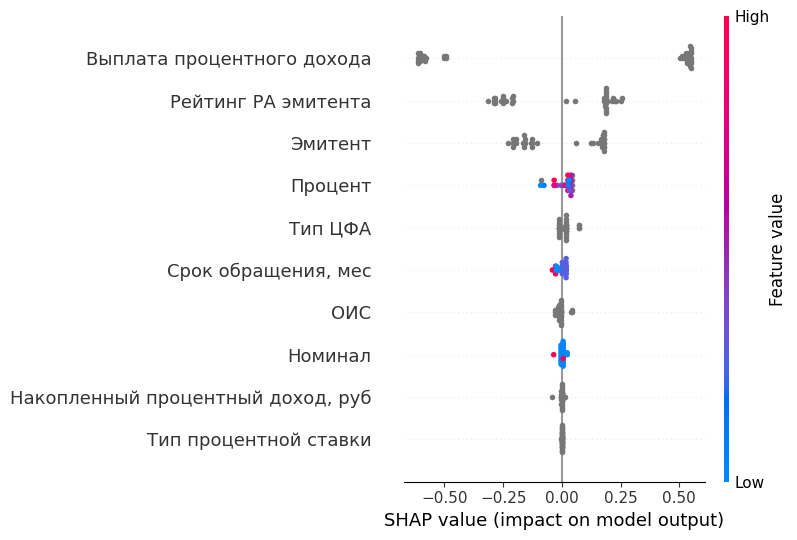

In [163]:
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(model_catb)

shap_values = explainer.shap_values(pool_test)

shap.summary_plot(
    shap_values,
    X_test,
    show = False
)

plt.savefig('shap_summary.png', dpi=300, bbox_inches='tight')

plt.show()

In [164]:
import os
os.getcwd()

'c:\\python study'

In [165]:
X_test = X_test.replace(['Na', 'nan'], np.nan)

C:\Users\User\AppData\Local\Temp\ipykernel_39556\446230336.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_test = X_test.replace(['Na', 'nan'], np.nan)


In [166]:
X_test['Процент'].dtype

dtype('float64')

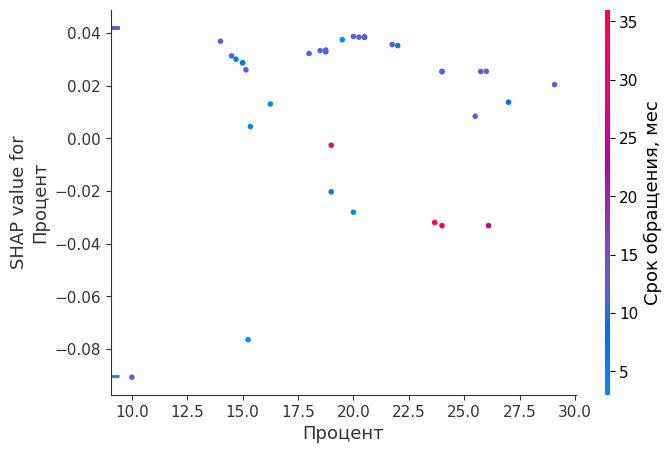

In [172]:
shap.dependence_plot(
    'Процент',
    shap_values,
    X_test,
    show = False
)

plt.savefig('percent_srok.png', dpi=300, bbox_inches='tight')

plt.show()

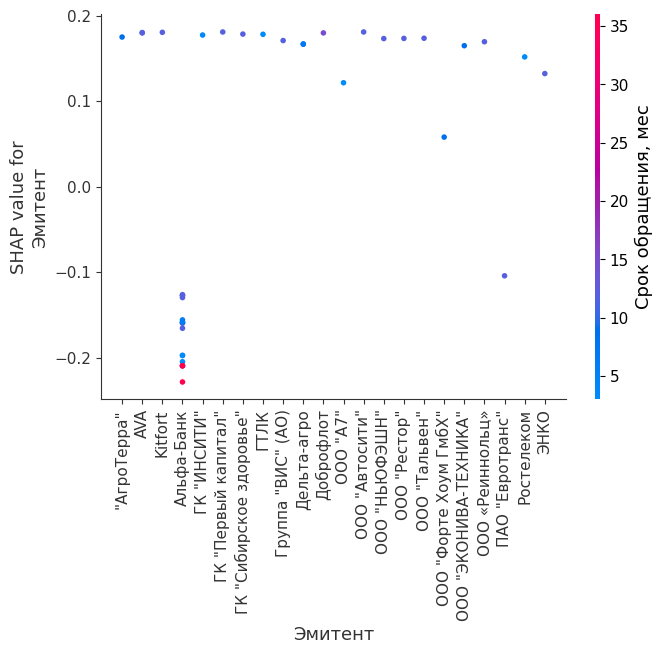

In [179]:
shap.dependence_plot(
    'Эмитент',
    shap_values,
    X_test,
    show = False
)

plt.savefig('emitents.png', dpi=300, bbox_inches='tight')

plt.show()

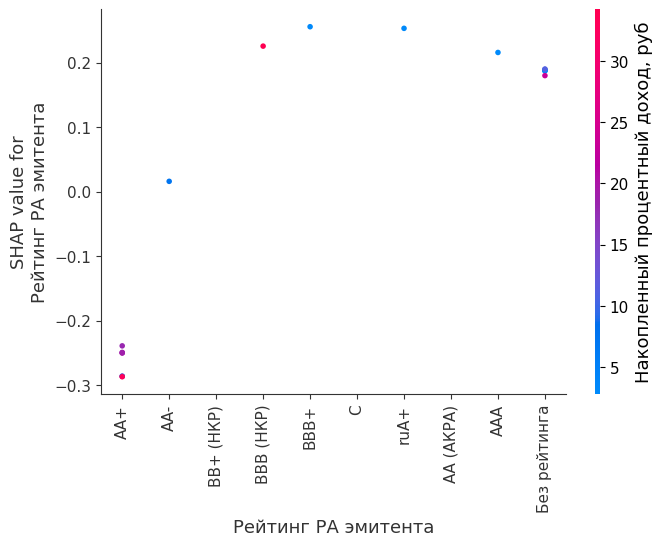

In [169]:
shap.dependence_plot(
    'Рейтинг РА эмитента',
    shap_values,
    X_test,
    show = False
)

plt.savefig('рейтинг.png', dpi=300, bbox_inches='tight')

plt.show()


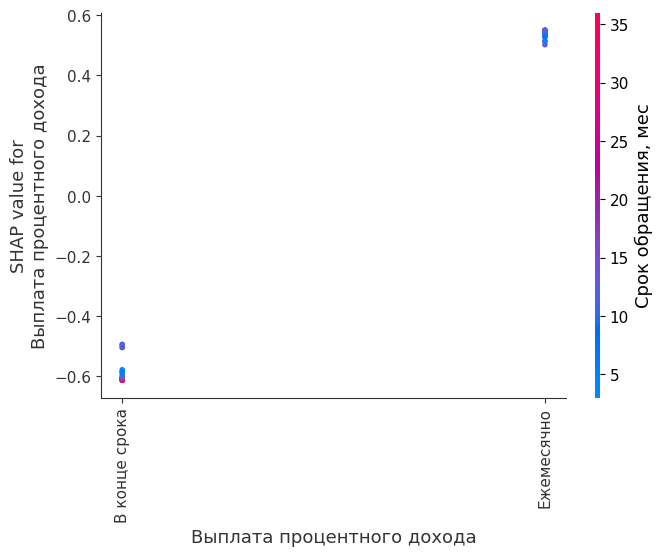

In [170]:
shap.dependence_plot(
    'Выплата процентного дохода',
    shap_values,
    X_test,
    show = False
)

plt.savefig('выплата.png', dpi=300, bbox_inches='tight')

plt.show()

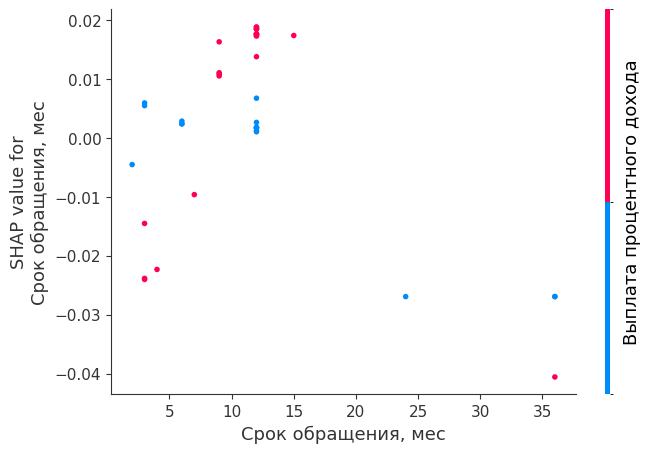

In [181]:
shap.dependence_plot(
    'Срок обращения, мес',
    shap_values,
    X_test,
    show = False
)

plt.savefig('срок.png', dpi=300, bbox_inches='tight')

plt.show()

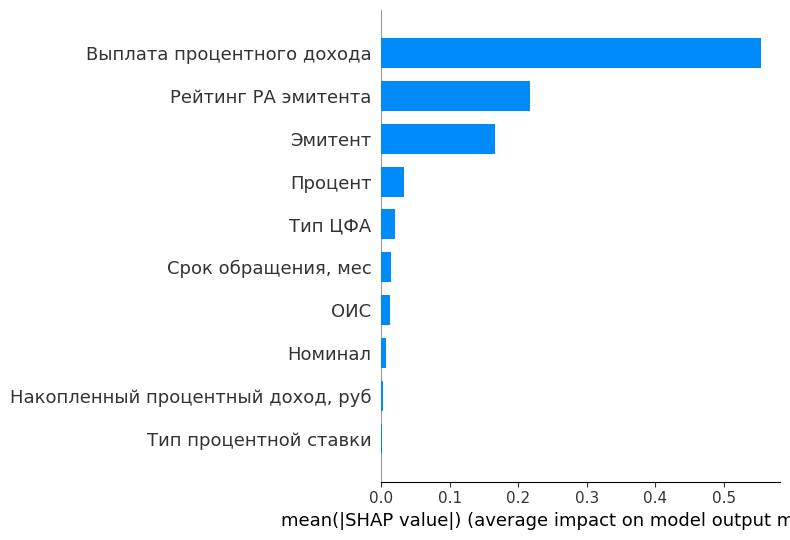

In [180]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type='bar',
    show = False
)


plt.savefig('mean.png', dpi=300, bbox_inches='tight')

plt.show()